# The Equation for Success: Effort, Opportunity, and Consistency
## Exploring the Key Drivers for Student Performance

-----

Author: Abnerson Ocampo

Email: abnersonocampo@gmail.com

Date: Jan 26, 2025

Data: Kaggle (Student Performance Dataset)

-------

## 1. Introduction

Success in academics is often influenced by multiple factors, ranging from individual effort and time management to external circumstances such as socioeconomic background and attendance. This analysis aims to uncover how these key drivers interact to shape student performance. Using the **Student Performance Dataset** from Kaggle, we explore questions like:  

- **Does studying longer directly lead to better grades?**  
- **How do socioeconomic factors influence academic outcomes?**  
- **Does consistent attendance provide students with an edge in achieving higher scores?**  

Through **data visualization and statistical exploration**, we analyze the relationships between **study hours, socioeconomic scores, attendance, and grades**. By leveraging tools such as **correlation matrices, SHAP analysis, and feature importance rankings**, we move beyond surface-level trends to quantify **both direct and indirect** influences on academic performance.  

However, identifying key features is only part of the equation. To build a predictive model capable of estimating student grades based on these factors, we implement **Machine Learning Models**, including:  
- **Linear Regression** for capturing linear relationships.  
- **Decision Trees** to detect non-linear patterns.  
- **Random Forest Regressor**, an ensemble model that ultimately outperformed the others in predictive accuracy.  

To ensure **generalizability and avoid overfitting**, we fine-tune our best-performing model through **Hyperparameter Tuning** and evaluate its performance across training and test data. Finally, we deploy our refined model to predict grades for new students, assessing its real-world applicability.  

By the end of this analysis, we aim to uncover the **"formula for success"**—blending **effort, opportunity, and consistency**—to provide data-driven insights into improving educational outcomes. 

-----------------

### Importing Libraries

In [1]:
import time # added first to calculate total run time
start_time = time.time()  # Record the start time

In [2]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis
from scipy.stats import pearsonr
import pingouin as pg

# Data Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

# Machine Learning Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Model Evaluation & Metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# SHAP for Explainability
import shap

# Model Saving & Loading
import joblib

### Data Loading

In [3]:
path = "student_performance.csv" # set the path
df = pd.read_csv(path) # read the path

---

## 2. Data Overview

#### Original Columns
| Column Name              | Description                                                                 |
|--------------------------|-----------------------------------------------------------------------------|
| Socioeconomic Score      | A normalized score (0-1) indicating the student's socioeconomic background. |
| Study Hours             | The number of hours a student studies per week.                            |
| Sleep Hours             | The number of hours a student sleeps per day.                              |
| Attendance (%)          | The percentage of classes attended by the student.                         |
| Grades                 | The final score achieved by the student (out of 100).                      |


#### Feature-Engineered Columns
| Column Name                     | Description                                                                            |
|----------------------------------|----------------------------------------------------------------------------------------|
| Socioeconomic Group             | A categorical label Low (Bottom 33%), Medium (Middle 33%), High (Top 33%) based on the Socioeconomic Score.             |
| Encoded Socioeconomic Group     | A numerical encoding of the Socioeconomic Group: Low = 0, Medium = 1, High = 2.       |

---

In [4]:
print("Dataset Information:\n")
df.info() # shows a brief summary of the dataset showing the non-nulls and data type

print("\nData Preview")
df.head() # shows the first 5 rows of the dataset

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1388 entries, 0 to 1387
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Socioeconomic Score  1388 non-null   float64
 1   Study Hours          1388 non-null   float64
 2   Sleep Hours          1388 non-null   float64
 3   Attendance (%)       1388 non-null   float64
 4   Grades               1388 non-null   float64
dtypes: float64(5)
memory usage: 54.3 KB

Data Preview


,Socioeconomic Score,Study Hours,Sleep Hours,Attendance (%),Grades
0,0.95822,3.4,8.2,53.0,47.0
1,0.85566,3.2,5.9,55.0,35.0
2,0.68025,3.2,9.3,41.0,32.0
3,0.25936,3.2,8.2,47.0,34.0
4,0.60447,3.8,10.0,75.0,33.0


## 3. Data Cleaning and Preparation

The dataset used in this analysis is from Kaggle and has already been cleaned. Since the data is already in a cleaned state, the following steps were carried out to ensure the data was fully prepared for this analysis:
- Double Checking for Null Values
- Verify Data Types
- Verifying if Data is Properly Standardized 
- Exploratory Check for Anomalies (Extreme Outliers)
- Feature Engineering - created a new column to aid the analysis

In [5]:
# Check null values
print("Null Values:\n")
print(df.isnull().sum())

# Check data types
print("\nData Types:\n")
print(df.info())

Null Values:

Socioeconomic Score    0
Study Hours            0
Sleep Hours            0
Attendance (%)         0
Grades                 0
dtype: int64

Data Types:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1388 entries, 0 to 1387
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Socioeconomic Score  1388 non-null   float64
 1   Study Hours          1388 non-null   float64
 2   Sleep Hours          1388 non-null   float64
 3   Attendance (%)       1388 non-null   float64
 4   Grades               1388 non-null   float64
dtypes: float64(5)
memory usage: 54.3 KB
None


-------------

### Feature Engineering

#### Socioeconomic Group Feature

In [6]:
# Categorize students into three socioeconomic groups based on their Socioeconomic Score
df["Socioeconomic Group"] = pd.qcut( # Quantile Cut
    df["Socioeconomic Score"],  # The column to be divided into quantiles
    q = [0, 0.33, 0.66, 1],  # Define the quantile cut points (Bottom 33%, Middle 33%, Top 33%)
    labels = ["Bottom 33%", "Middle 33%", "Top 33%"]  # Assign labels to each quantile group
)

### Encoding

In [7]:
# Apply Ordinal Encoding
df["Encoded Socioeconomic Group"] = df["Socioeconomic Group"].map({
    "Bottom 33%" : 0,
    "Middle 33%" : 1,
    "Top 33%" : 2
})

df.head()

,Socioeconomic Score,Study Hours,Sleep Hours,Attendance (%),Grades,Socioeconomic Group,Encoded Socioeconomic Group
0,0.95822,3.4,8.2,53.0,47.0,Top 33%,2
1,0.85566,3.2,5.9,55.0,35.0,Top 33%,2
2,0.68025,3.2,9.3,41.0,32.0,Middle 33%,1
3,0.25936,3.2,8.2,47.0,34.0,Bottom 33%,0
4,0.60447,3.8,10.0,75.0,33.0,Middle 33%,1


---

## 4. Exploratory Data Analysis (EDA)

In [8]:
# General Statistics Summary
df.describe()

,Socioeconomic Score,Study Hours,Sleep Hours,Attendance (%),Grades
count,1388.000000,1388.000000,1388.000000,1388.000000,1388.000000
mean,0.552274,4.560807,8.047262,58.536023,40.691643
std,0.261272,1.897581,1.370700,11.675287,9.467358
min,0.101280,0.800000,4.800000,40.000000,32.000000
25%,0.322118,3.475000,7.000000,49.000000,34.000000
50%,0.545945,3.900000,8.400000,57.000000,35.000000
75%,0.789610,5.900000,9.100000,66.000000,47.000000
max,0.999820,10.000000,10.000000,100.000000,91.000000


### Determining Central Tendency and the Working Range using the IQR method

**Outlier Analysis Using the IQR Method**

To better understand the range and distribution of student grades, I applied the Interquartile Range (IQR) method to identify potential outliers. This method calculates lower and upper bounds as follows:

Lower Bound =  Q1 - 1.5 * IQR 

Upper Bound =  Q3 + 1.5 * IQR 

After calculating these bounds, I found no extreme outliers, and only a few data points fall outside this range. The few mild outliers are within plausible values for grades and may represent meaningful insights.

In [9]:
central_tendency = {
    "mean" : df["Grades"].mean(), # Grade mean
    "median" : df["Grades"].median() # Grade median
}

measures_of_dispersion = {
    "variance" : df["Grades"].var(), # Grade variance
    "std_dev" : df["Grades"].std() # Grade standard deviation
}

# get the full range of the grades
student_grade_range = {
    "min" : df["Grades"].min(),
    "max": df["Grades"].max(),
    "range" : df["Grades"].max() - df["Grades"].min()
}

Q1 = df["Grades"].quantile(0.25) # Q1
Q2 = df["Grades"].quantile(0.5) # Q2 (Median)
Q3 = df["Grades"].quantile(0.75) # Q3
IQR = Q3 - Q1 # IQR
lower_bound = Q1 - 1.5 * IQR # Lower Bound
upper_bound = Q3 + 1.5 * IQR # Upper Bound


# Print Summary
print(f"""
    Summary:

    Central Tendency Measures:  
    Mean: {central_tendency["mean"].__round__(2)}
    Median: {central_tendency["median"]}
    Range: {student_grade_range["range"]}

    Dispersion Measures:
    Variance: {measures_of_dispersion["variance"].__round__(2)}
    Standard Deviation: {measures_of_dispersion["std_dev"].__round__(2)}

    Quartile1: {Q1}
    Quartile2(median): {Q2}
    Quartile3: {Q3}
    IQR: {IQR}
    Lower Bound: {lower_bound}
    Upper Bound: {upper_bound}
    Working Range: [{lower_bound}, {upper_bound}]
""")



    Summary:

    Central Tendency Measures:  
    Mean: 40.69
    Median: 35.0
    Range: 59.0

    Dispersion Measures:
    Variance: 89.63
    Standard Deviation: 9.47

    Quartile1: 34.0
    Quartile2(median): 35.0
    Quartile3: 47.0
    IQR: 13.0
    Lower Bound: 14.5
    Upper Bound: 66.5
    Working Range: [14.5, 66.5]



-----

### A General Overview of the Dataset ###

#### Skewness of the Data

In [10]:
print(df[['Study Hours', 'Sleep Hours', 'Attendance (%)', 'Grades', 'Socioeconomic Score']].skew())

Study Hours            0.670101
Sleep Hours           -0.596974
Attendance (%)         0.631172
Grades                 1.416299
Socioeconomic Score    0.015592
dtype: float64


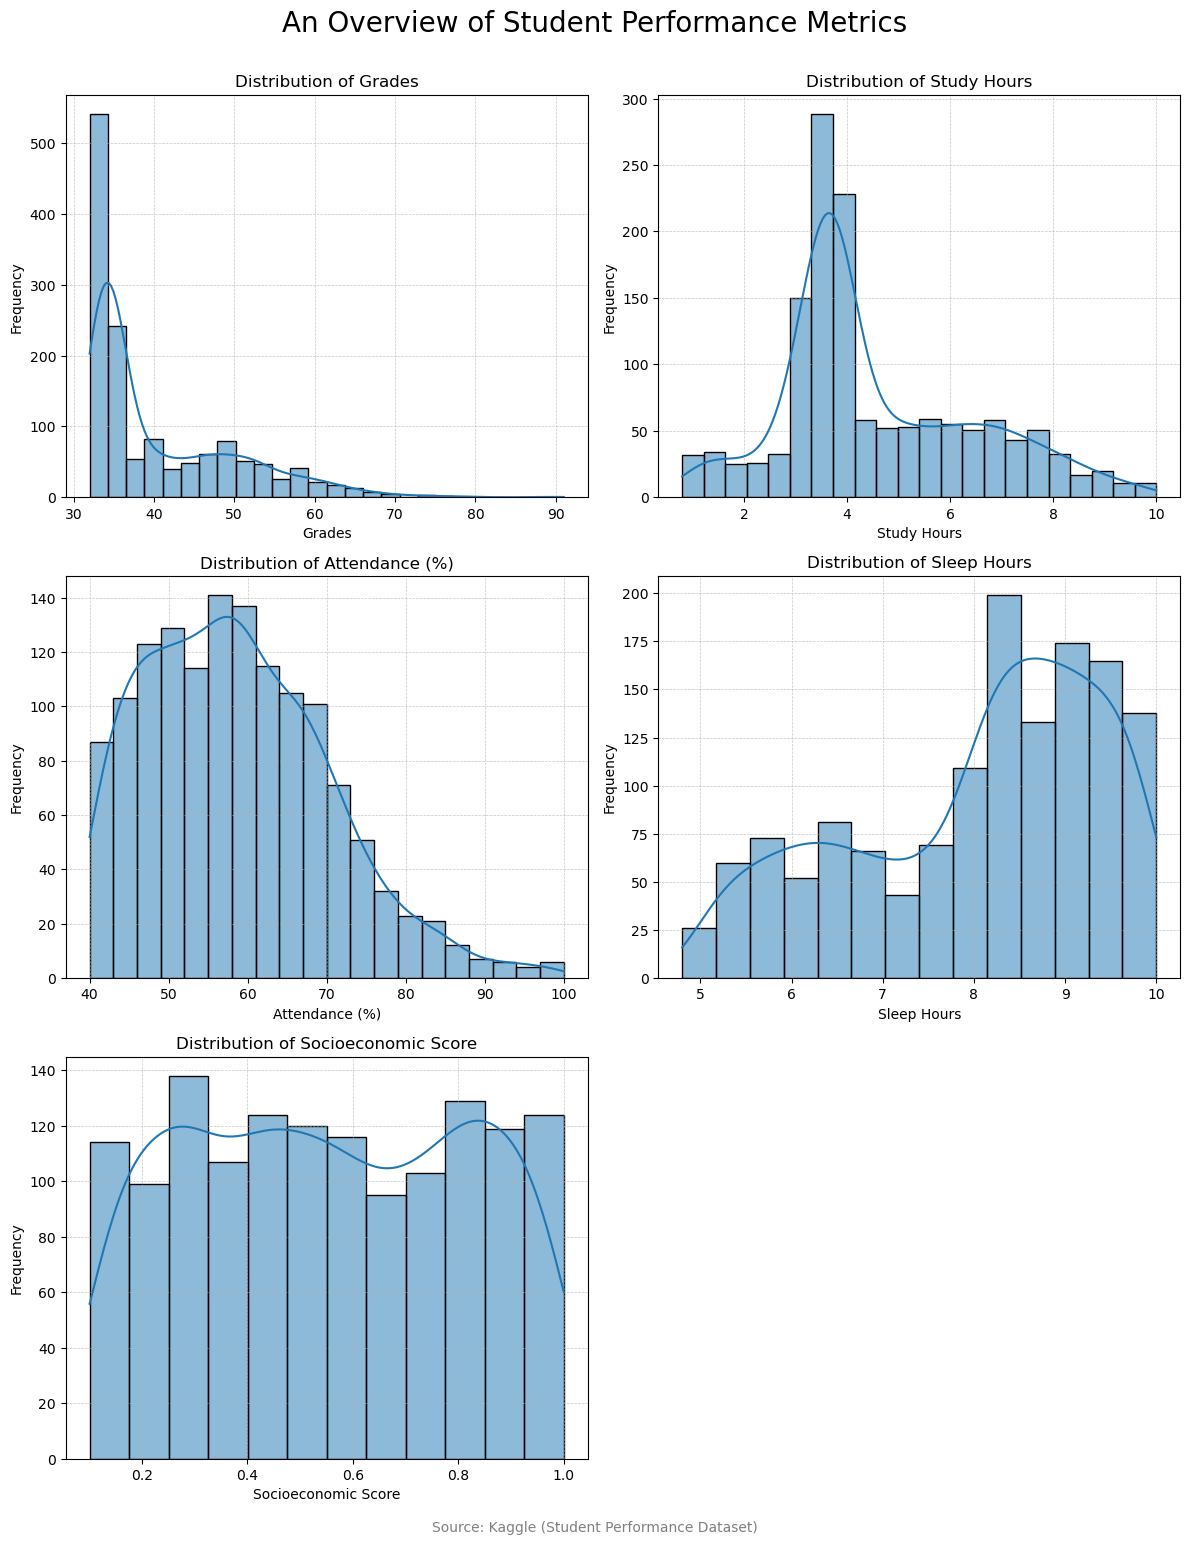

In [11]:
selected_columns = ["Grades", "Study Hours", "Attendance (%)", "Sleep Hours", "Socioeconomic Score"]

plt.figure(figsize = (12, 15)) # make the plot 12 inches wide and 15 inches tall
for i, column in enumerate(selected_columns, 1): # loop through all the columns in the df
    plt.subplot(3, 2, i) # make the plot a 2 plots wide and 3 plots tall with i as the counter from the loop
    sns.histplot(df[column], kde=True)  # make a histogram
    plt.title(f"Distribution of {column}") # Title of the individual plots
    plt.ylabel("Frequency") # y axis label
    plt.grid(True, # Turn on the grid lines
             which="both", # turn on both vertical and horizontal grid lines
             linestyle = "--", # dashed style
             linewidth = 0.5, # line width
             alpha = 0.7)# transparency
# Super Title for the whole plot
plt.suptitle("An Overview of Student Performance Metrics",
             fontsize = 20, # super title size
             y = 1.005) # vertical alignment
# Caption for source data
plt.figtext(0.5, -0.01, 
            "Source: Kaggle (Student Performance Dataset)", 
            wrap=True, horizontalalignment='center', 
            fontsize = 10, 
            color='gray')
plt.tight_layout() # avoids overlaps
plt.show() # show figure

### Exploring Possible Correlations in the Dataset: **Correlation Matrix** + **Pair Plot** ###

#### **Correlation Matrix**

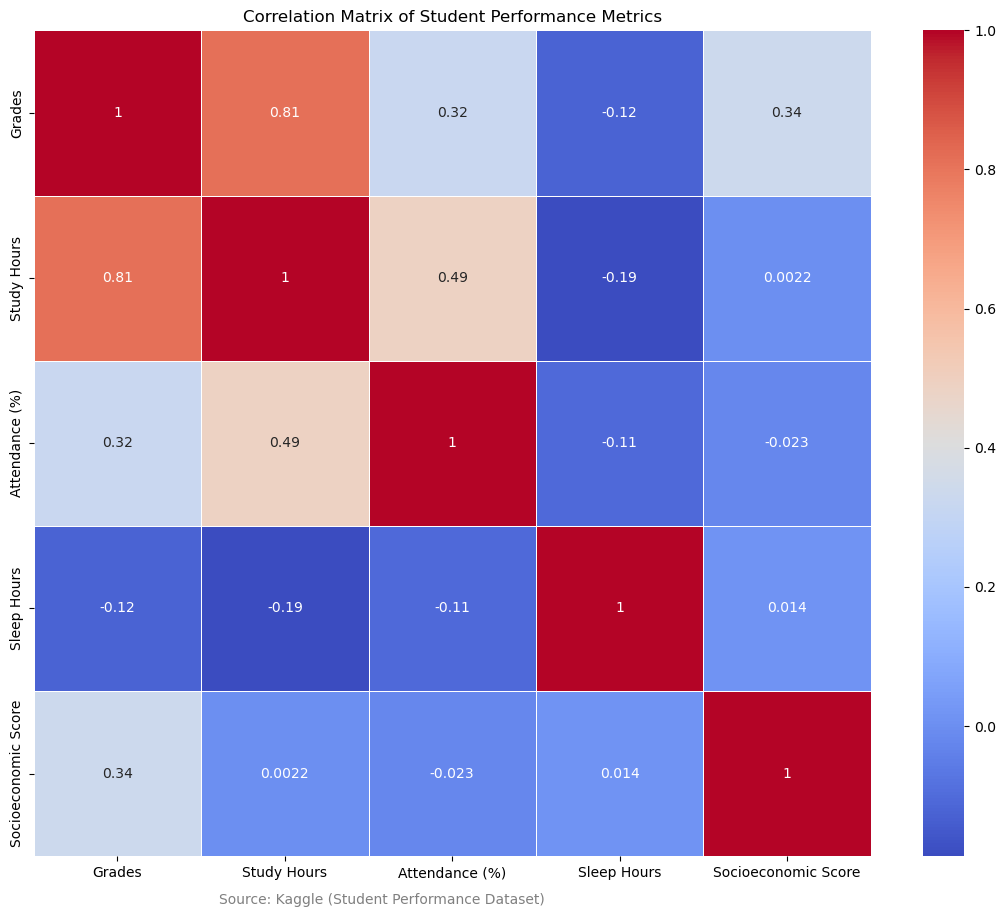

In [12]:
plt.figure(figsize=(11, 9)) # make the plot 11 inches wide and 9 inches tall
corr = df[selected_columns].corr() # correlation of columns, correlation coefficients ranging from -1 to 1
sns.heatmap(corr,  # make a heatmap
            annot=True, # annotations = True
            cmap='coolwarm', # color map
            linewidths = 0.5) # line width
plt.title('Correlation Matrix of Student Performance Metrics') # Plot Title
plt.figtext(0.5, -0.01, # Caption for the source data
            "Source: Kaggle (Student Performance Dataset)", 
            wrap=True, # makes sure it doesn't overflow outside the canvas
            horizontalalignment='right',
            fontsize=10, 
            color='gray')
plt.tight_layout()
plt.show()

#### **Pair Plot**

<Figure size 1300x1000 with 0 Axes>

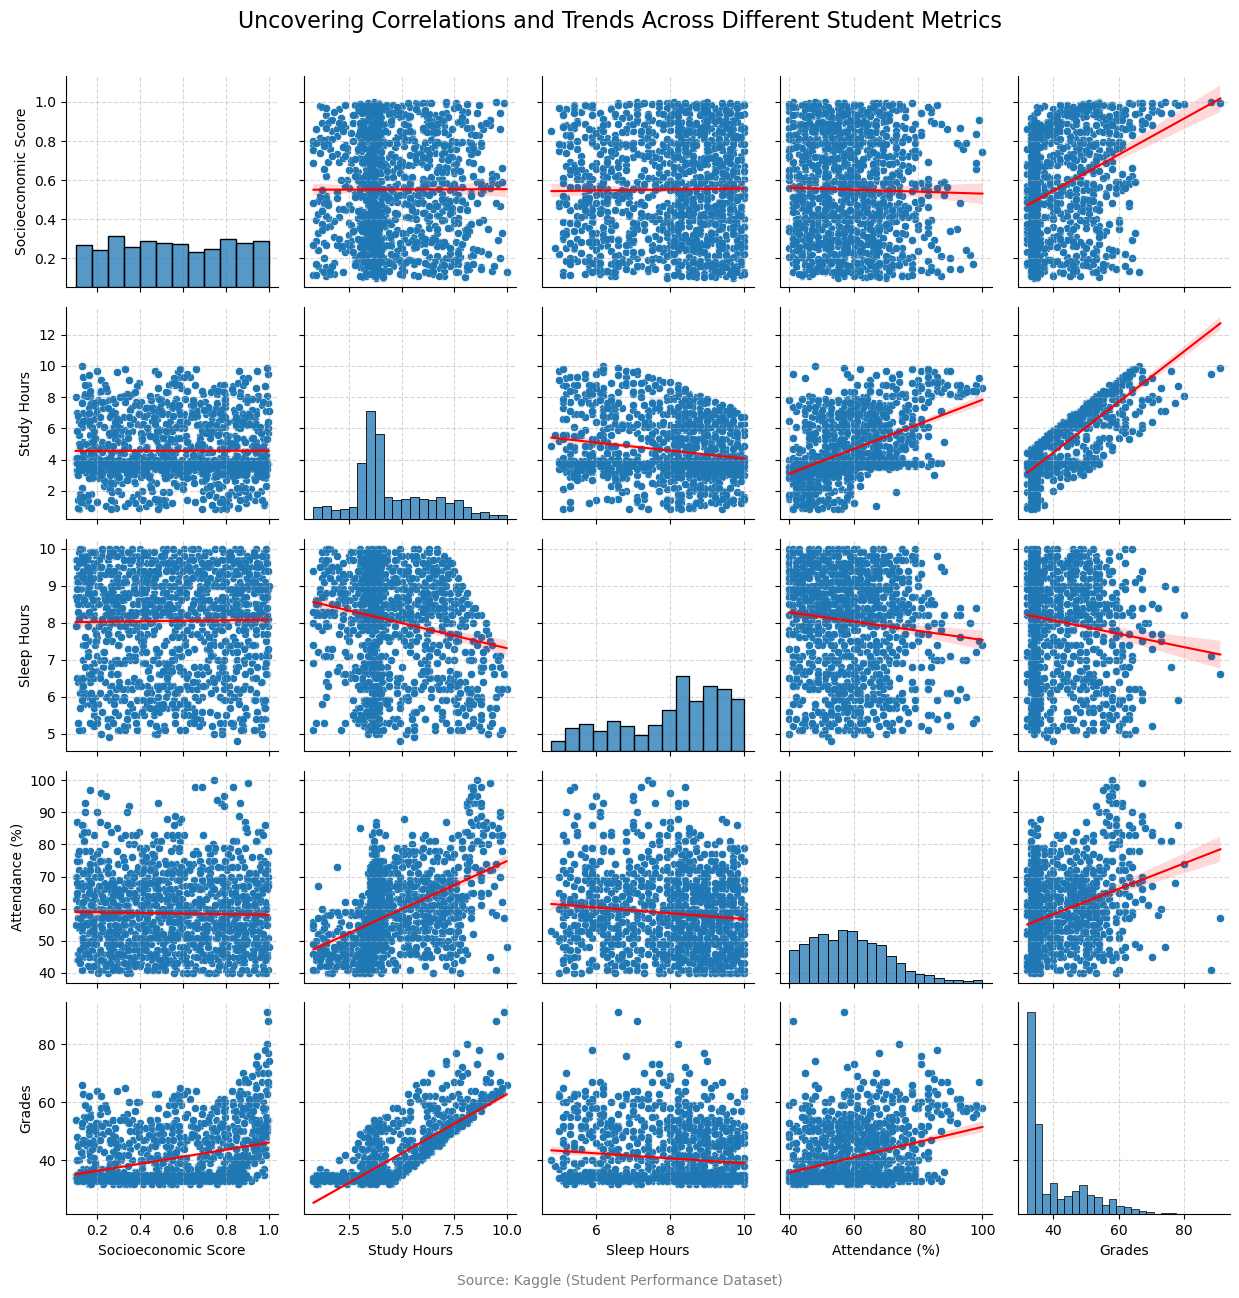

In [13]:
plt.figure(figsize = (13, 10)) # Set the figure size 13 inches wide and 10 inches tall
# Doing it this way will apply it to every single plot in the diagram
pairplot = sns.pairplot(df, # data source
                        diag_kind = "hist"
                        ) # makes sure the histogram diagonal is kept
pairplot.figure.suptitle("Uncovering Correlations and Trends Across Different Student Metrics", # super title
                         fontsize = 16, # size
                         y = 1.01) # adjust vertical position for the title
pairplot.map(lambda *args, **kwargs: # on the spot function so you don't have to define a separate one
             plt.grid(True, # turn on gridlines
                      linestyle="--", # use dashed gridlines
                      alpha=0.5)) # gridline transparency
pairplot.map_offdiag(
    sns.regplot, # add a regression line
    scatter_kws={"s": 10, # point size
                 "alpha": 0.7},  # point transparency
    line_kws={"color": "red",  # regression line color
              "linewidth": 1.5}  # regression line width
)
plt.figtext(0.5, -0.01, 
            "Source: Kaggle (Student Performance Dataset)", 
            wrap=True, 
            horizontalalignment='center', 
            fontsize=10, 
            color='gray')
pairplot.figure.tight_layout() # avoids overlaps
plt.show() # show the figure

----

### **Observation**: We see that study hours may be correlated to student grades. Let's explore it further. ###

---

#### **Hypothesis Test**: Is there a strong connection between Study Hours and Grades, or is it just a myth?
To test this, we will use the **Pearson Correlation Test**, which helps us measure both the strength and significance of this relationship.

---

**Hypothesis Statement**:

*Null Hypothesis*: There is no significant correlation between Study Hours and Grades.

*Alternative Hypothesis*: There is a significant positive correlation between Study Hours and Grades.

In [14]:
r_value, p_value = pearsonr(df["Study Hours"], df["Grades"])

print(f"Pearson Correlation Coefficient: {r_value:.4f}")
print(f"P-Value: {p_value:.4e}")

Pearson Correlation Coefficient: 0.8108
P-Value: 0.0000e+00


---

**Key Findings**:

A correlation of **0.8108** means there is a **strong positive relationship** between Study Hours and Grades, suggesting that students who *study more* tend to achieve *higher grades*.

A P-Value of **0.0000** tells us that the *association* is **statistically significant**, meaning the chances of this happening randomly are nearly **zero**! 

Since **p < 0.05**, we **reject the null hypothesis** and conclude that there is a significant positive correlation between Study Hours and Grades.

---

**Statistical Validation**:

In [15]:
# Compute Pearson correlation with confidence interval
pearson_results = pg.corr(df["Study Hours"], df["Grades"])

# Display results
print(pearson_results)

            n         r         CI95%  p-val BF10  power
pearson  1388  0.810807  [0.79, 0.83]    0.0  inf    1.0


A **95% confidence interval ([0.79, 0.83])** suggests that the *true correlation* is likely within this range, further strengthening our confidence in these findings.

Additionally, the **Bayes Factor (BF10 = ∞)** provides overwhelming evidence in favor of the alternative hypothesis, strongly suggesting that Study Hours influence Grades. The test also achieved a **power of 1.0**, indicating that it is extremely reliable with virtually no risk of a false negative

---

*Now that we know this relationship is real, let’s visualize it. If Study Hours truly affect Grades, we should see a clear trend in a scatterplot. Let’s take a deeper dive and see if the data aligns with our expectations!*

#### **Scatterplot**: A deeper dive into the relationship of Hours of Study and Student Grades

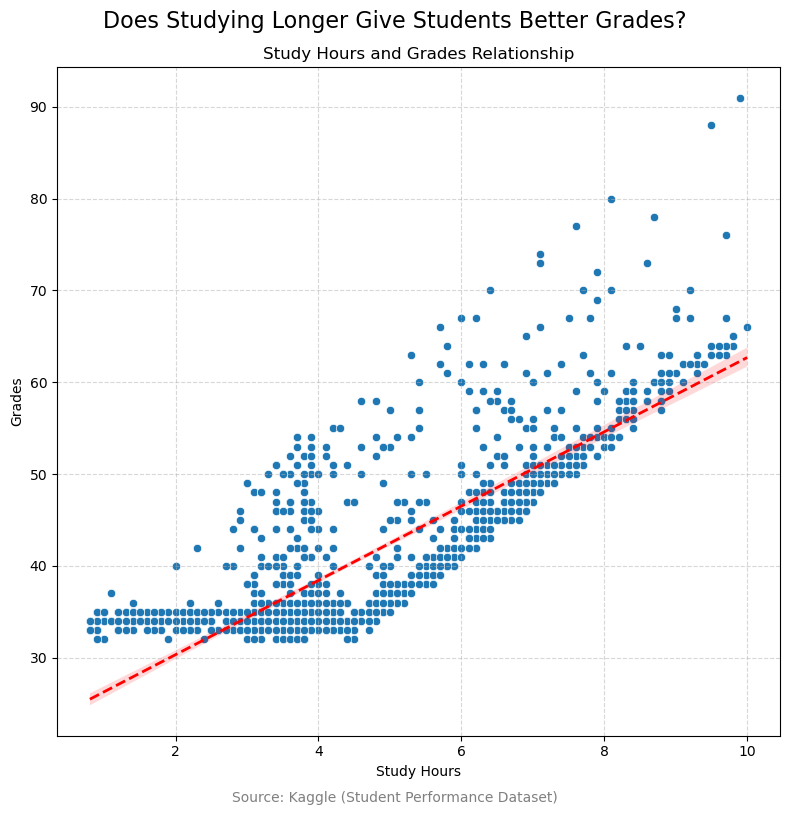

In [16]:
plt.figure(figsize = (8, 8)) # Set figure size to 8x8 inches
sns.scatterplot(
    data = df,
    x = "Study Hours",
    y = "Grades" # Create scatterplot for Study Hours vs. Grades
)
sns.regplot(
    data = df, 
    x = "Study Hours", 
    y = "Grades",
    scatter = False, # Disable scatter points in regplot (handled by scatterplot above)
    line_kws = {"color": "red",  # Regression line color
                "linestyle": "--",  # Regression line style (dashed)
                "linewidth": 2}  # Regression line thickness
)
plt.suptitle("Does Studying Longer Give Students Better Grades?", fontsize=16) # Add a supertitle
plt.title("Study Hours and Grades Relationship", fontsize=12) # Add a subtitle below the supertitle
plt.xlabel("Study Hours") # Label the x-axis
plt.ylabel("Grades") # Label the y-axis
plt.figtext(
    0.5, -0.01,  # Set the position of the text (centered horizontally, slightly below the plot)
    "Source: Kaggle (Student Performance Dataset)", # Caption for data source
    wrap = True,  # Allow text wrapping
    horizontalalignment = 'center',  # Align text horizontally to the center
    fontsize = 10,  # Set font size for the caption
    color = 'gray' # Set text color for the caption
)
plt.grid(True, axis="both", linestyle="--", alpha=0.5) # Enable gridlines with dashed style and transparency
plt.tight_layout() # Adjust spacing to prevent overlap
plt.show() # Display the plot

### **Insights**: The More You Study, the Better You Score!

 -  The plot shows a positive correlation between Study Hours and Student Grades. As students study more, their grades tend to increase. This trend is reinforced by the regression line, which highlights the overall direction of the relationship.
 -  Outliers: A few students had high grades (80-90) even with fewer study hours. Could this represent naturally talented or highly efficient learners? Or are there other factors involved? Socioeconomic background? Attendance?

---

#### Do students with better socioeconomic backgrounds score more despite studying less? Or do students with great attendance naturally have better grades? Let's dive deeper!

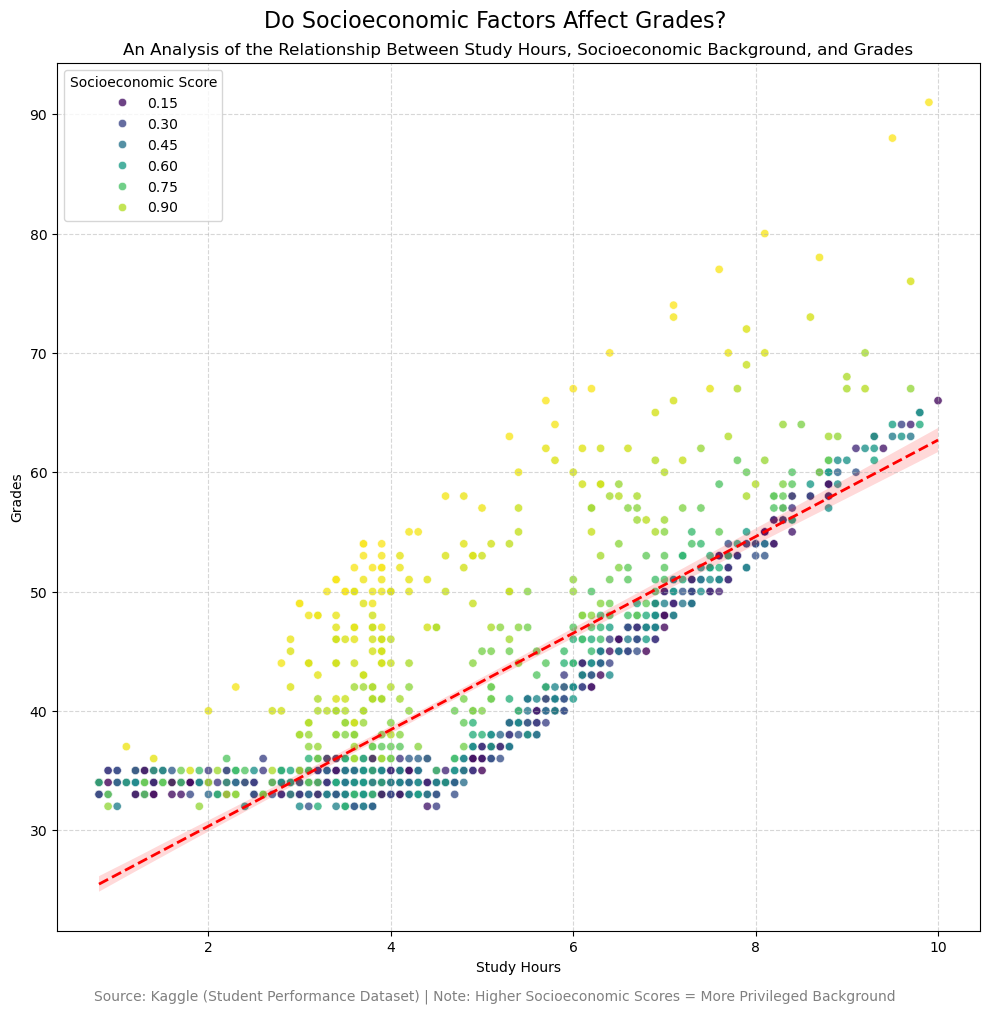

In [17]:
plt.figure(figsize = (10, 10)) # Set figure size to 10x10 inches
sns.scatterplot(
    data = df,
    x = "Study Hours", # X-axis: Study Hours
    y = "Grades", # Y-axis: Grades
    hue = "Socioeconomic Score", # Use Socioeconomic Score to color points
    palette = "viridis", # Use the 'viridis' colormap for the hue
    alpha = 0.8 # Set transparency level for points
)
sns.regplot(
    data = df, 
    x = "Study Hours", 
    y = "Grades",
    scatter = False, # Disable scatter points in regplot (handled by scatterplot above)
    line_kws = {"color": "red", # Regression line color
                "linestyle": "--", # Regression line style (dashed)
                "linewidth": 2} # Regression line thickness
)
plt.suptitle("Do Socioeconomic Factors Affect Grades?", fontsize=16) # Add a supertitle
plt.title("An Analysis of the Relationship Between Study Hours, Socioeconomic Background, and Grades", fontsize=12) # Add a subtitle below the supertitle
plt.xlabel("Study Hours") # Label the x-axis
plt.ylabel("Grades") # Label the y-axis
plt.figtext(
    0.5, -0.01, # Position the caption (centered horizontally, slightly below the plot)
    "Source: Kaggle (Student Performance Dataset) | Note: Higher Socioeconomic Scores = More Privileged Background", # Caption for data source
    wrap = True, # Allow text wrapping
    horizontalalignment = 'center', # Align text horizontally to the center
    fontsize = 10, # Font size for the caption
    color = 'gray' # Text color for the caption
)
plt.grid(True, axis="both", linestyle="--", alpha=0.5) # Enable gridlines with dashed style and transparency
plt.tight_layout() # Adjust spacing to prevent overlap
plt.show() # Display the plot

### Insights: Yes! Socioeconomic Factors Absolutely Play a Role in Student Grades!

-   Higher socioeconomic scores (lighter green/yellow dots) cluster towards higher grades, even with fewer study hours
-   Students with lower socioeconomic scores (purple/blue dots) tend to have lower grades, even if they study for more hours
-   The plot suggests that socioeconomic factors provide a significant advantage, potentially enabling students from higher backgrounds to achieve better grades with less effort
-   Likely due to access to more resources, such as tutors, educational materials, technology, reduced external stressors, and better study environments.

#### Additional Data on Socioeconomic Factor

<Figure size 1300x1000 with 0 Axes>

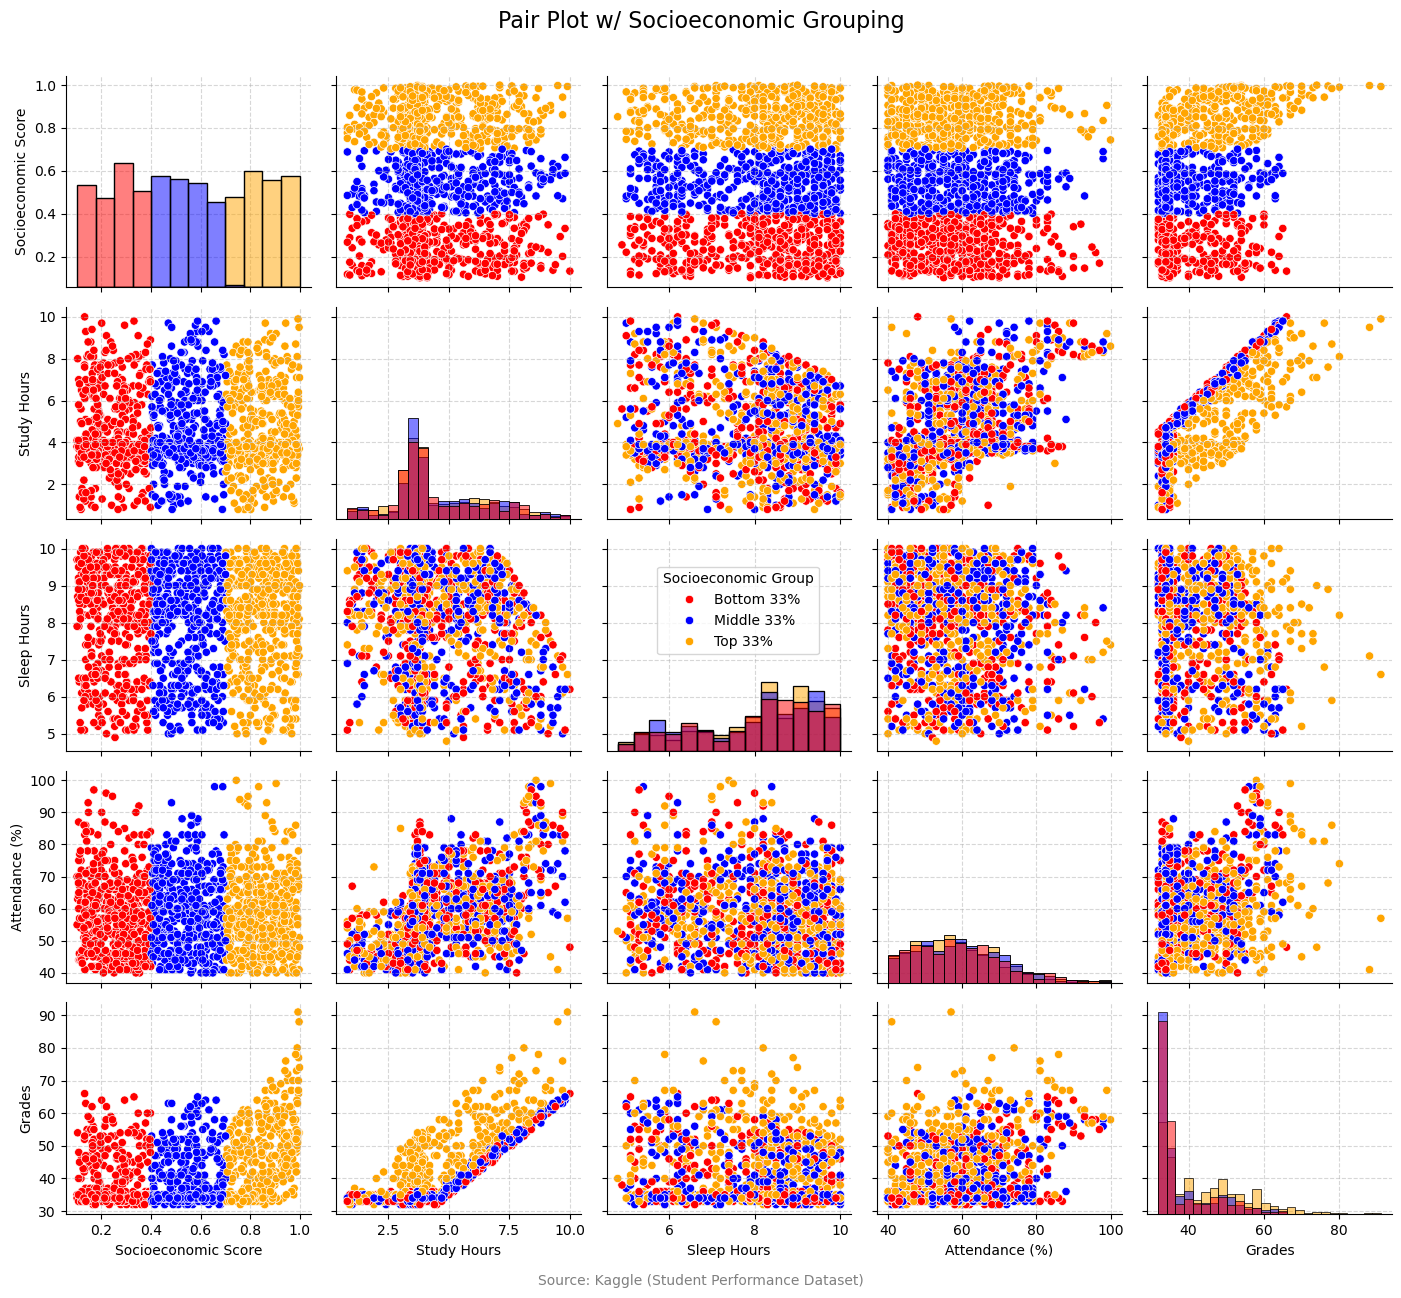

In [18]:
plt.figure(figsize = (13, 10)) # Set the figure size 13 inches wide and 10 inches tall
# Doing it this way will apply it to every single plot in the diagram
pairplot = sns.pairplot(df, # data source
                        hue = "Socioeconomic Group",
                        diag_kind = "hist",
                        palette={"Top 33%": "orange", "Middle 33%": "blue", "Bottom 33%" : "red"} 
                        ) # makes sure the histogram diagonal is kept
pairplot.figure.suptitle("Pair Plot w/ Socioeconomic Grouping", # super title
                         fontsize = 16, # size
                         y = 1.01) # adjust vertical position for the title
pairplot.map(lambda *args, **kwargs: # on the spot function so you don't have to define a separate one
             plt.grid(True, # turn on gridlines
                      linestyle="--", # use dashed gridlines
                      alpha=0.5)) # gridline transparency
plt.figtext(0.5, -0.01, 
            "Source: Kaggle (Student Performance Dataset)", 
            wrap=True, 
            horizontalalignment='center', 
            fontsize=10, 
            color='gray')
pairplot._legend.set_bbox_to_anchor((0.585, 0.55))  # Move the legend outside to the right
pairplot._legend.set_title("Socioeconomic Group")  # Set legend title
pairplot._legend.set_frame_on(True) # Turns on the legend frame
pairplot.figure.tight_layout() # avoids overlaps
plt.show() # show the figure

------

### How About Attendance? Is it a factor to Student Scores?

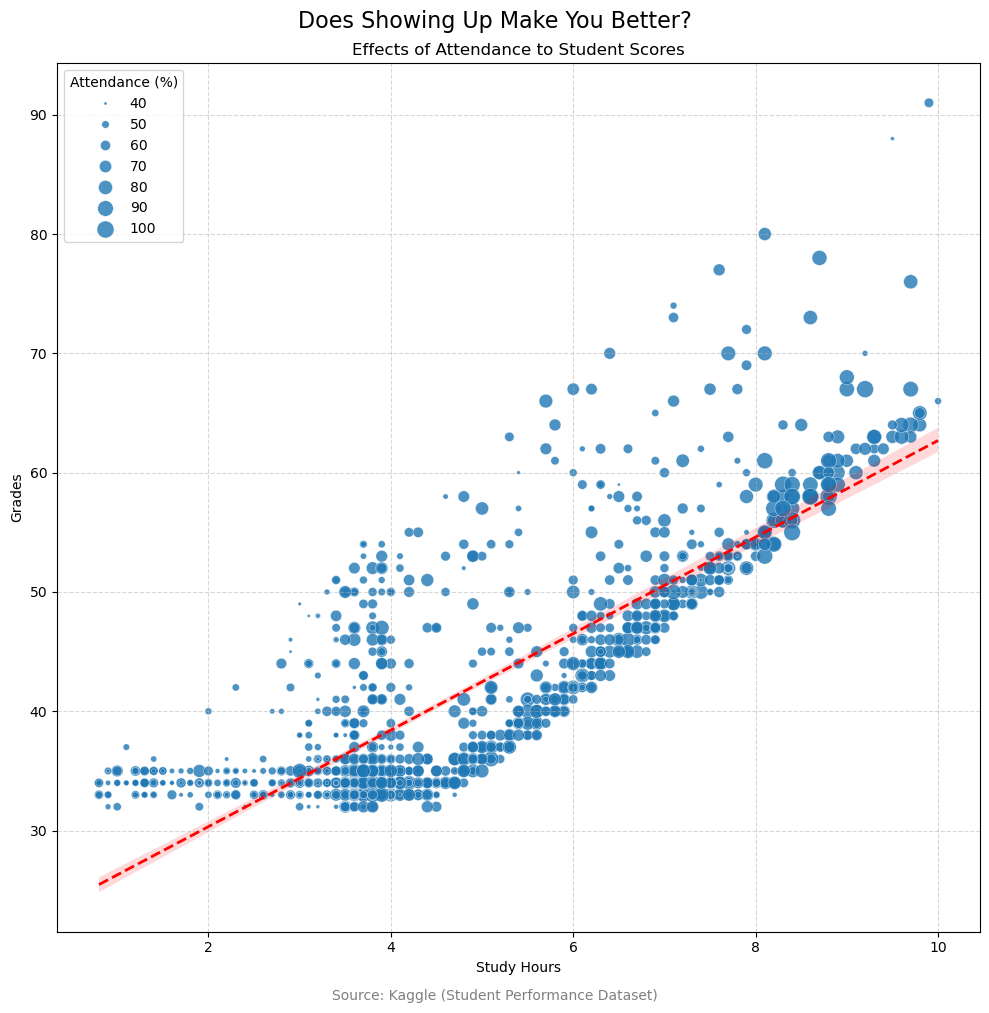

In [19]:
plt.figure(figsize = (10, 10)) # Set figure size to 10x10 inches
sns.scatterplot(
    data = df,
    x = "Study Hours", # X-axis: Study Hours
    y = "Grades", # Y-axis: Grades
    size = "Attendance (%)", # Use Attendance (%) to adjust point size
    sizes = (5, 150), # Define the range of point sizes
    alpha = 0.8 # Set transparency level for points
)
sns.regplot(
    data = df, 
    x = "Study Hours", 
    y = "Grades",
    scatter = False, # Disable scatter points in regplot (handled by scatterplot above)
    line_kws = {"color": "red", # Regression line color
                "linestyle": "--", # Regression line style (dashed)
                "linewidth": 2} # Regression line thickness
)
plt.suptitle("Does Showing Up Make You Better?", fontsize=16) # Add a supertitle
plt.title("Effects of Attendance to Student Scores", fontsize=12) # Add a subtitle below the supertitle
plt.xlabel("Study Hours") # Label the x-axis
plt.ylabel("Grades") # Label the y-axis
plt.figtext(
    0.5, -0.01, # Position the caption (centered horizontally, slightly below the plot)
    "Source: Kaggle (Student Performance Dataset)", # Caption for data source
    wrap = True, # Allow text wrapping
    horizontalalignment = 'center', # Align text horizontally to the center
    fontsize = 10, # Font size for the caption
    color = 'gray' # Text color for the caption
)
plt.grid(True, axis="both", linestyle="--", alpha=0.5) # Enable gridlines with dashed style and transparency
plt.tight_layout() # Adjust spacing to prevent overlap
plt.show() # Display the plot

#### Insights: Consistency is Key--or is it?
-   The size of the points, representing attendance percentage, suggests that students with higher attendance (larger points) generally align with better grades
-   The largest points are clustered on the rightmost side of the scatter plot, where Study Hours are the highest. 
-   This emphasizes the importance of consistent attendance in achieving better academic performance
-   But how important is it really? Can we somehow verify and quantify it?

---

### Putting Them Together

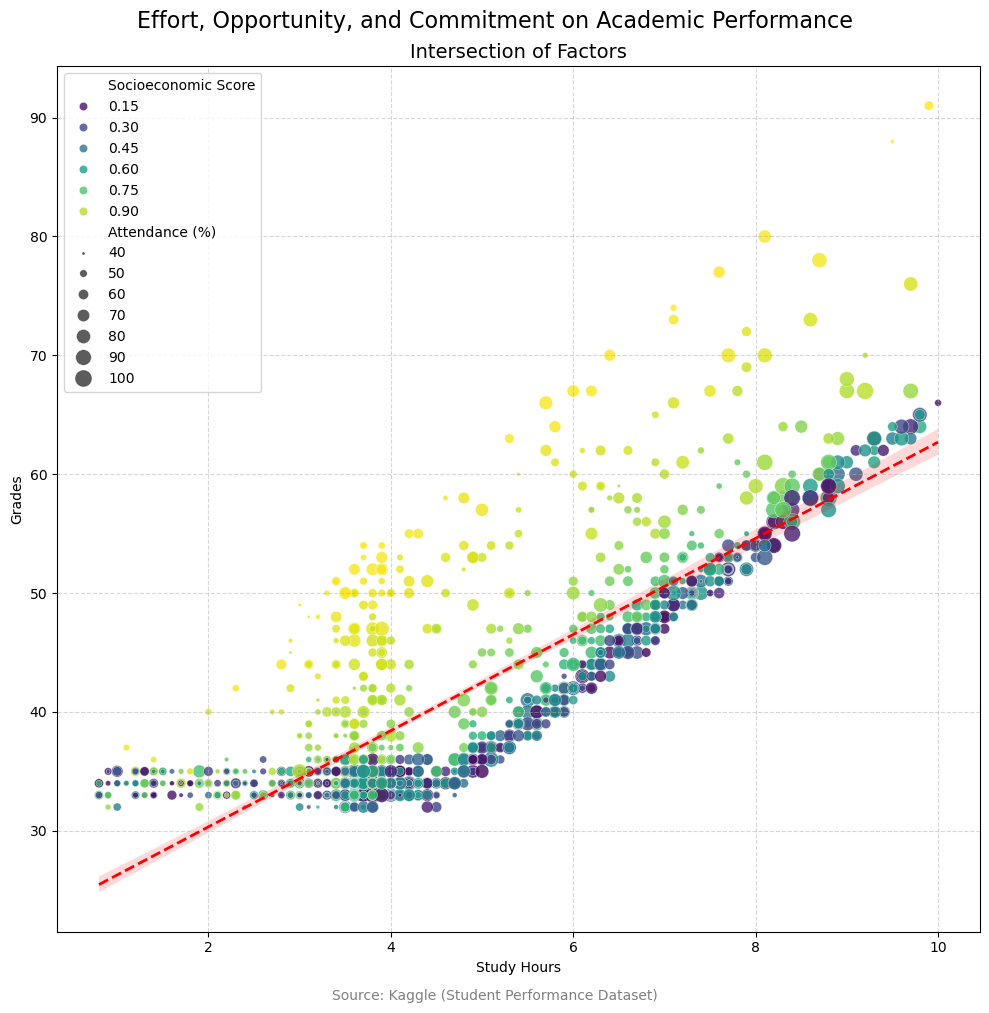

In [20]:
plt.figure(figsize = (10, 10)) # Set figure size to 10x10 inches
sns.scatterplot(
    data = df,
    x = "Study Hours", # X-axis: Study Hours
    y = "Grades", # Y-axis: Grades
    hue = "Socioeconomic Score", # Use Socioeconomic Score to color points
    palette = "viridis", # Set color palette to viridis for hue
    size = "Attendance (%)", # Use Attendance (%) to adjust point size
    sizes = (5, 150), # Define the range of point sizes
    alpha = 0.8 # Set transparency level for points
)
sns.regplot(
    data = df, 
    x = "Study Hours", 
    y = "Grades",
    scatter = False, # Disable scatter points in regplot (handled by scatterplot above)
    line_kws = {"color": "red", # Regression line color
                "linestyle": "--", # Regression line style (dashed)
                "linewidth": 2} # Regression line thickness
)
plt.suptitle("Effort, Opportunity, and Commitment on Academic Performance", fontsize=16) # Add a supertitle
plt.title("Intersection of Factors", fontsize=14) # Add a subtitle below the supertitle
plt.xlabel("Study Hours") # Label the x-axis
plt.ylabel("Grades") # Label the y-axis
plt.figtext(
    0.5, -0.01, # Position the caption (centered horizontally, slightly below the plot)
    "Source: Kaggle (Student Performance Dataset)", # Caption for data source
    wrap = True, # Allow text wrapping
    horizontalalignment = 'center', # Align text horizontally to the center
    fontsize = 10, # Font size for the caption
    color = 'gray' # Text color for the caption
)
plt.grid(True, axis="both", linestyle="--", alpha=0.5) # Enable gridlines with dashed style and transparency
plt.tight_layout() # Adjust spacing to prevent overlap
plt.show() # Display the plot

**NOTE**: Sleep Hours was also tested but shown no significant interaction.

---

### **Seeing the Pattern VS. Proving the Pattern: Correlation VS. Causation**
**Quantifying Multivariate Relationships and Hidden Interactions Beyond Bivariate Analysis**

At this point, our investigation seemed to reveal a compelling story. Our scatter plot combining Study Hours, Socioeconomic Score, and Attendance (%) painted what looked like a multivariate relationship. Larger dots—representing high attendance—often clustered around higher grades, reinforcing the idea that showing up more frequently led to better academic performance.

But in data science, seeing a pattern is only the first step. The real challenge is proving whether it actually exists.

So, the next step in our journey was to go beyond visuals and truly quantify these relationships. Was attendance really modifying the effect of Study Hours on Grades? Or we're we falling for a misleading correlation? To answer that, we turned to SHAP—a powerful tool designed to break down model predictions and expose the true influence of each factor.

With SHAP, we wouldn’t just rely on patterns—we’d measure the actual impact of each variable on Grades and test if Attendance (%) was truly driving student success.

Let’s put our assumptions to the test.

---

#### **SHAP Summary Plot: Feature Importance**

Before testing for interactions, we first confirm if our individual features (Study Hours, Socioeconomic Score, Attendance (%), etc.) significantly impact Grades.
- This validates the bivariate relationships we explored in EDA.
- We ensure that features like Study Hours and Socioeconomic Score actually contribute to predictions.
- If a feature has low SHAP importance, it’s unlikely to have a strong interaction.

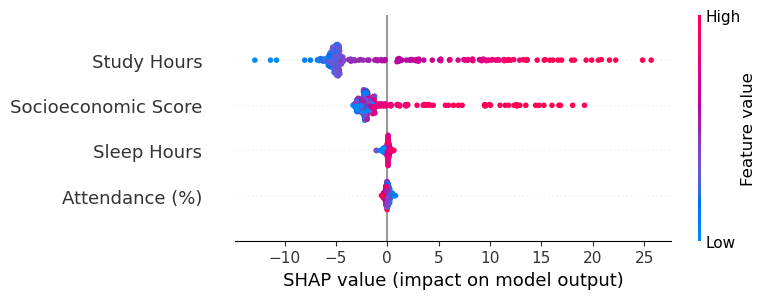

In [21]:
# Define features and target
features = ["Socioeconomic Score", "Study Hours", "Sleep Hours", "Attendance (%)"]
target_column = "Grades"

# Separate X (features) and y (target)
X = df[features]
y = df[target_column]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a baseline Random Forest model
baseline_rf = RandomForestRegressor(random_state=42)
baseline_rf.fit(X_train, y_train)  # Train it

# Convert X_test back to DataFrame after StandardScaler
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Create SHAP Explainer
explainer = shap.TreeExplainer(baseline_rf)
shap_values = explainer.shap_values(X_test_df)

# SHAP Summary Plot with Feature Names
shap.summary_plot(shap_values, X_test_df, feature_names=X_test_df.columns)

**Insights:**

The SHAP summary plot provides a global view of feature importance and how each variable influences the model’s predictions for student grades.
- Study Hours has the highest impact on predicted grades, confirming that the more time spent studying, the greater the effect on academic performance.
- Socioeconomic Score follows as the second most influential factor, suggesting that economic background plays a role in student success.
- Sleep Hours has a moderate impact, reinforcing that sleep patterns might be linked to cognitive performance.
- Attendance (%) appears to have the least effect, aligning with our SHAP dependence plot results, where its influence on Study Hours was minimal.

---

#### **Verifying our Multivariate Relationship Findings**
Now that we know which features are important, we move to feature interactions using SHAP dependence plots to prove our multivariate correlation findings.

- The scatter plot (EDA) made it seem like Socioeconomic Score and Attendance (%) interacted with Study Hours and Grades.
- SHAP dependence plots will confirm or disprove these observations.
- If color trends show interaction, the feature modifies another’s effect.

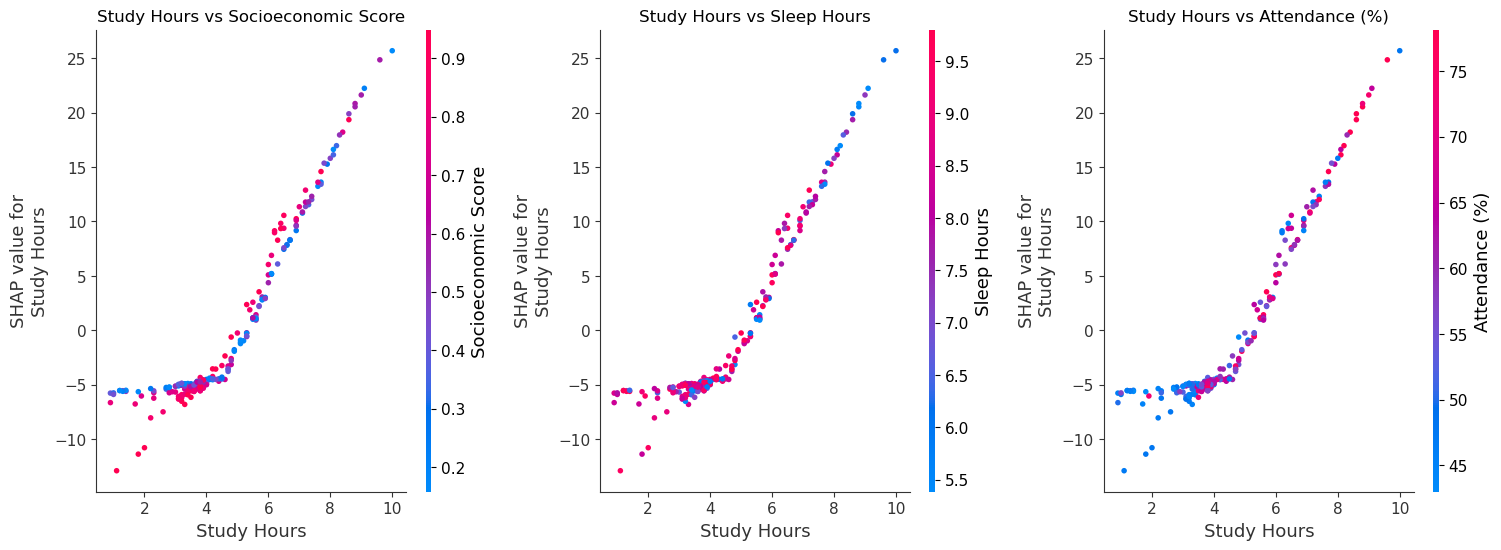

In [22]:
# Set up a figure with three subplots in one row
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Generate SHAP dependence plots and direct them to respective subplots
shap.dependence_plot("Study Hours", shap_values, X_test_df, interaction_index="Socioeconomic Score", ax=axes[0], show=False)
axes[0].set_title("Study Hours vs Socioeconomic Score")

shap.dependence_plot("Study Hours", shap_values, X_test_df, interaction_index="Sleep Hours", ax=axes[1], show=False)
axes[1].set_title("Study Hours vs Sleep Hours")

shap.dependence_plot("Study Hours", shap_values, X_test_df, interaction_index="Attendance (%)", ax=axes[2], show=False)
axes[2].set_title("Study Hours vs Attendance (%)")

# Adjust layout to prevent overlap
plt.subplots_adjust(wspace=0.3)  # Adjust spacing between subplots
plt.show()

**Insights:**

- At first glance, the size of the points (representing Attendance (%)) suggested a clear pattern—students with higher attendance seemed to score better.
- This led us to believe Attendance played a direct role in student performance, much like Study Hours.
- However, as we can see, further analysis with SHAP dependence plots revealed that Attendance does NOT significantly modify the impact of Study Hours on Grades—meaning the initial trend was just a correlation, not a cause-and-effect relationship.
- The real driver of success? Study Hours and Socioeconomic Score. While attendance and sleep hours may align with better grades, they don't independently boost them.

---

### **Model Selection & Predictive Analysis: Quantifying Key Relationships**

We observed a strong relationship in our visualizations. Now, let's formally ***quantify*** these relationships using a model to determine which factors best predict student grades. 

#### **Why Do We Need a Predictive Model?**

- Instead of just analyzing past data, prediction models help us estimate future values
- We can predict student grades based on study hours, attendance score etc.
- If a new student has 5 study hours, 80% attendance etc. a predictive model can predict their grade.
- School could use this to identify struggling students early and offer support!

---

#### **Model Selection Criteria**

Since our dataset deals with **continuous numerical** predictions, **regression models** like Linear Regression, Decision Trees, and Random Forests are the most appropriate tools for this analysis. We will compare multiple models to find the best fit for predicting student performance.

We will evaluate the different models based on the following metrics:

1. **Mean Squared Error (MSE)**:  
   - Measures the average squared difference between actual and predicted grades.  
   - A **lower MSE** means the model’s predictions are closer to the actual student grades.  

2. **Root Mean Squared Error (RMSE)**:  
   - Similar to MSE but takes the square root to provide an error metric in the same unit as the target variable (grades).  
   - A **lower RMSE** indicates better predictive performance.  

3. **Mean Absolute Error (MAE)**:  
   - Measures the average absolute difference between actual and predicted values.  
   - Unlike MSE, MAE is less sensitive to outliers and provides a more intuitive measure of average prediction error.  

4. **R² (Coefficient of Determination)**:  
   - Measures how well the independent variables (**Study Hours, Attendance, Socioeconomic Score**, etc.) explain the variance in **Grades**.  
   - A **higher R²** indicates that the model captures more of the relationship between student performance and the selected features.

In this analysis, we set **Grades** as the dependent variable and used all other columns as independent variables to predict student performance. The goal is to select a model that minimizes error while maximizing explanatory power.

---

 #### **Data Preprocesing for Model Selection**:

In [23]:
# Define the target variable
features = ["Socioeconomic Score", "Study Hours", "Sleep Hours", "Attendance (%)"]
target_column = "Grades"  # Specify the target column (replace with actual target if different)

# Separate features (X) and target variable (y)
X = df[features]  # Features
y = df[target_column]  # Target variable

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the feature variables
scaler = StandardScaler()  # Initialize the scaler

X_train_scaled = scaler.fit_transform(X_train)  # Fit on training data and transform
X_test_scaled = scaler.transform(X_test)  # Transform test data using the same parameters from training data

---

#### **Model Training, Evaluation, and Visualization**:

Regression Function

In [24]:
def train_evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)  # Train model
    y_pred = model.predict(X_test) # Make predictions

    print(f"{model.__class__.__name__} Results:\n")

    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Display
    print(f"MSE: {mse:.4f} (lower is better)")
    print(f"RMSE: {rmse:.4f} (lower is better)")
    print(f"MAE: {mae:.4f} (lower is better)")
    print(f"R2 Score: {r2:.4f} (higher is better)")

    # Check for Overfitting
    y_train_pred = model.predict(X_train)
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)

    print("\nOverfitting Test:")
    print(f"Train MSE: {train_mse:.4f}, Train R2: {train_r2:.4f}")
    print(f"Test MSE: {mse:.4f}, Test R2: {r2:.4f}")

    # Compute Residuals
    residuals = y_test - y_pred

    # Create subplots for side-by-side visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 7)) # 1 row, 3 columns

    ### Plot 1: Actual vs Predicted Values

    # Plot actual values as a background reference (spread along x-axis)
    axes[0].scatter(y_test, y_test, color = "blue", alpha = 0.3, label = "Actual Values", marker = "o")

    # Scatter plot for predicted values (in red)
    axes[0].scatter(y_test, y_pred, color = "red", alpha = 0.5, label = "Predicted Values", marker = "x")

    # Line representing perfect predictions (y = x)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], color="black", linestyle="--", linewidth=1, label="Perfect Fit")

    # Plot settings
    axes[0].set_title(f"{model.__class__.__name__}: Actual vs Predicted")
    axes[0].set_xlabel("Actual Values")
    axes[0].set_ylabel("Predicted Values")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.5)

    ### Plot 2: Residuals Plot
    axes[1].scatter(y_pred, residuals, color = "blue", alpha = 0.5)
    axes[1].axhline(y = 0, color = "black", linestyle = "--", linewidth = 1)  # Reference line at 0 residual

    # Plot Settings
    axes[1].set_title(f"{model.__class__.__name__}: Residuals Plot")
    axes[1].set_xlabel("Predicted Values")
    axes[1].set_ylabel("Residuals")
    axes[1].grid(True, linestyle="--", alpha = 0.5)

    # Plot 3: Bar Chart (Overfitting Check)
    bar_width = 0.3  # Thin bars
    metrics = ["MSE", "R²"]  # Only two metrics

    train_values = [train_mse, train_r2]  # Train scores
    test_values = [mse, r2]  # Test scores

    x = np.arange(len(metrics))  # X locations for the bars

    # Adjust subplot access correctly
    axes[2].bar(x - bar_width/2, train_values, bar_width, label="Train", color="green", alpha=0.7)
    axes[2].bar(x + bar_width/2, test_values, bar_width, label="Test", color="orange", alpha=0.7)

    axes[2].set_xticks(x)
    axes[2].set_xticklabels(metrics)
    axes[2].set_title(f"{model.__class__.__name__}: Overfitting Check")
    axes[2].set_ylabel("Score")
    axes[2].legend()
    axes[2].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

    return model # Return Trained Model

---

#### **Running the Models**

LinearRegression Results:

MSE: 19.2725 (lower is better)
RMSE: 4.3900 (lower is better)
MAE: 3.3862 (lower is better)
R2 Score: 0.7447 (higher is better)

Overfitting Test:
Train MSE: 20.4656, Train R2: 0.7798
Test MSE: 19.2725, Test R2: 0.7447


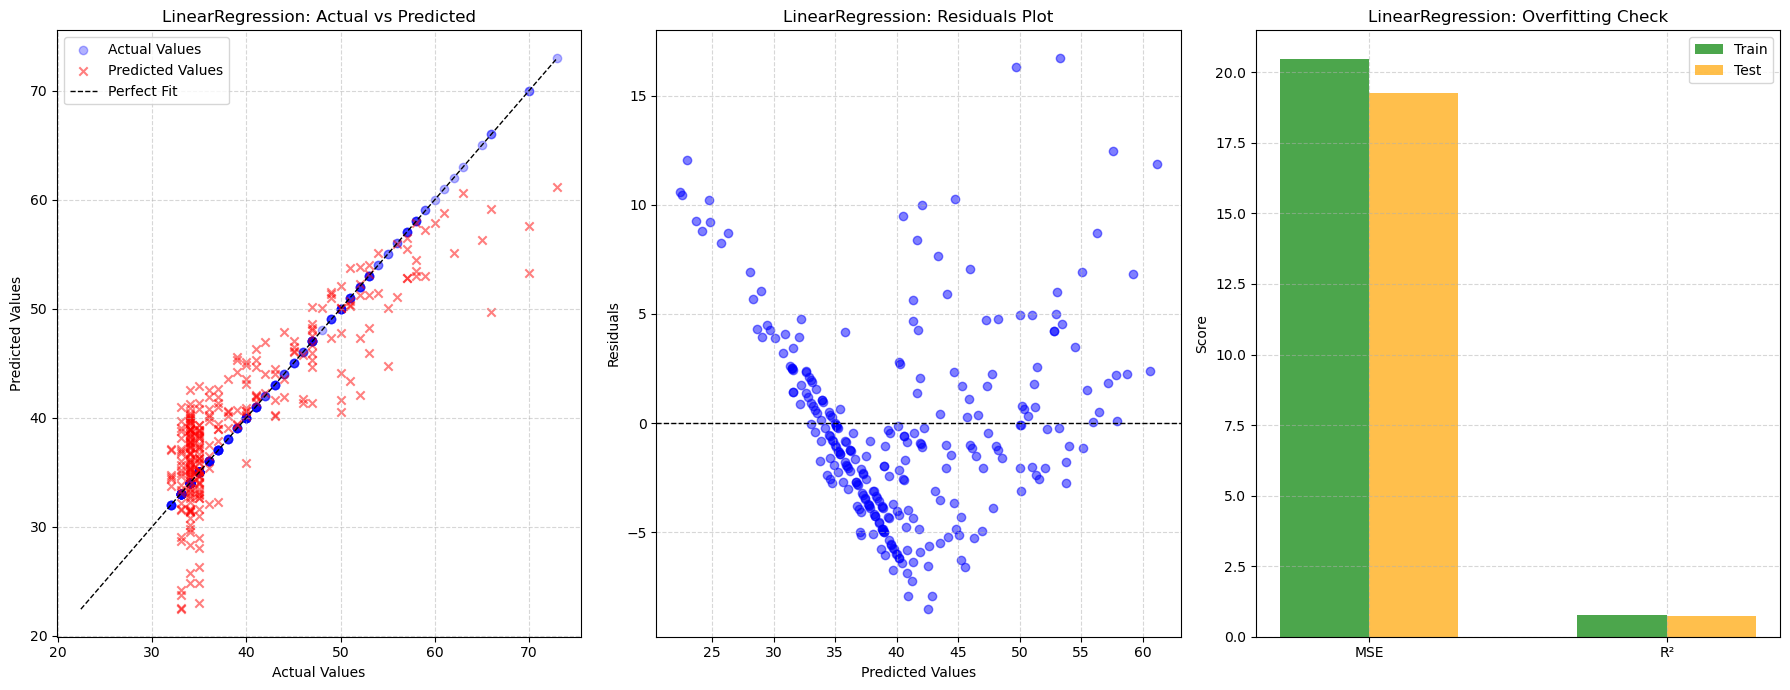

DecisionTreeRegressor Results:

MSE: 3.5971 (lower is better)
RMSE: 1.8966 (lower is better)
MAE: 1.3165 (lower is better)
R2 Score: 0.9523 (higher is better)

Overfitting Test:
Train MSE: 0.0000, Train R2: 1.0000
Test MSE: 3.5971, Test R2: 0.9523


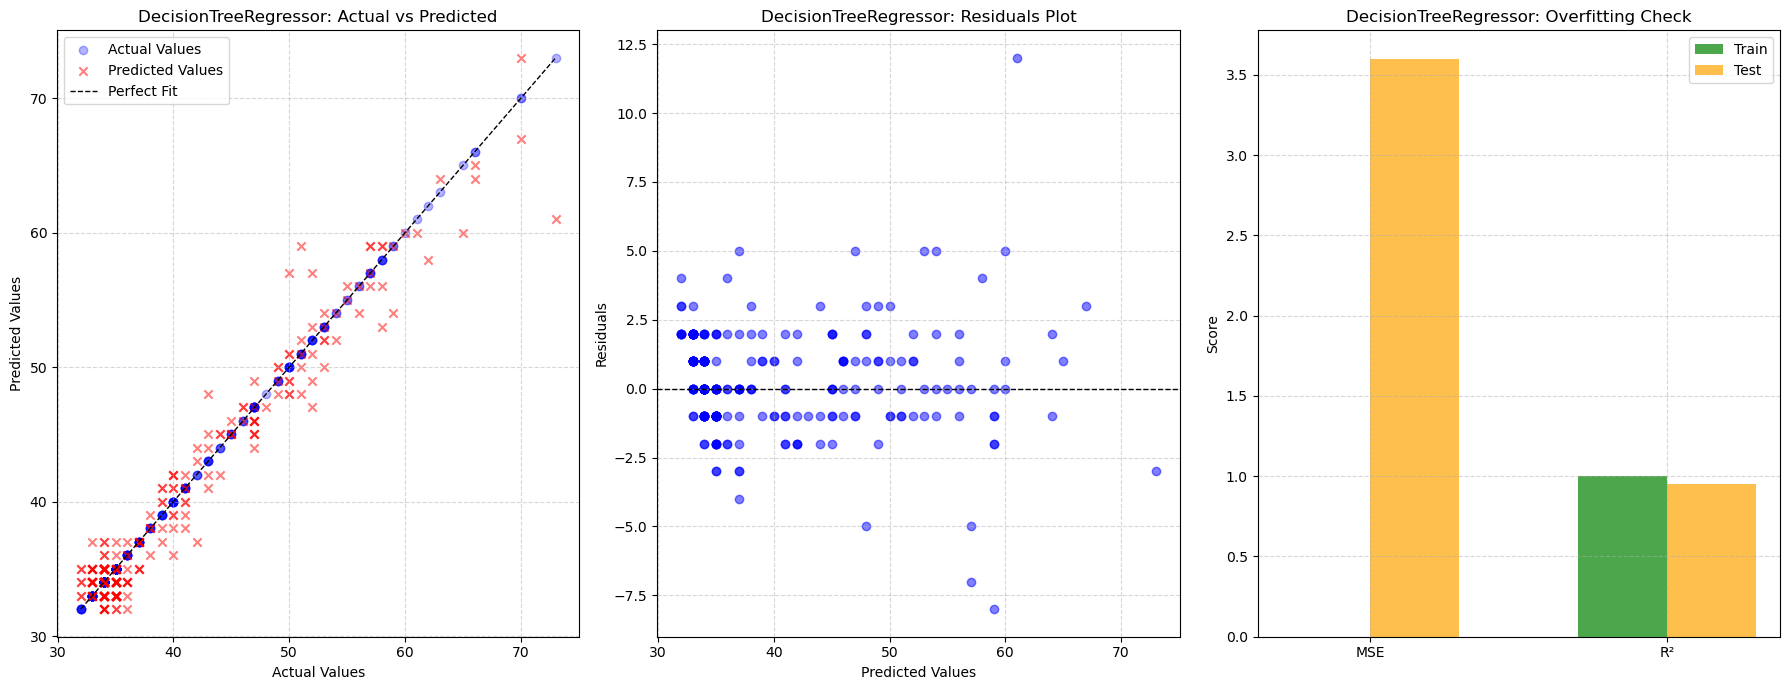

RandomForestRegressor Results:

MSE: 1.4634 (lower is better)
RMSE: 1.2097 (lower is better)
MAE: 0.8930 (lower is better)
R2 Score: 0.9806 (higher is better)

Overfitting Test:
Train MSE: 0.2860, Train R2: 0.9969
Test MSE: 1.4634, Test R2: 0.9806


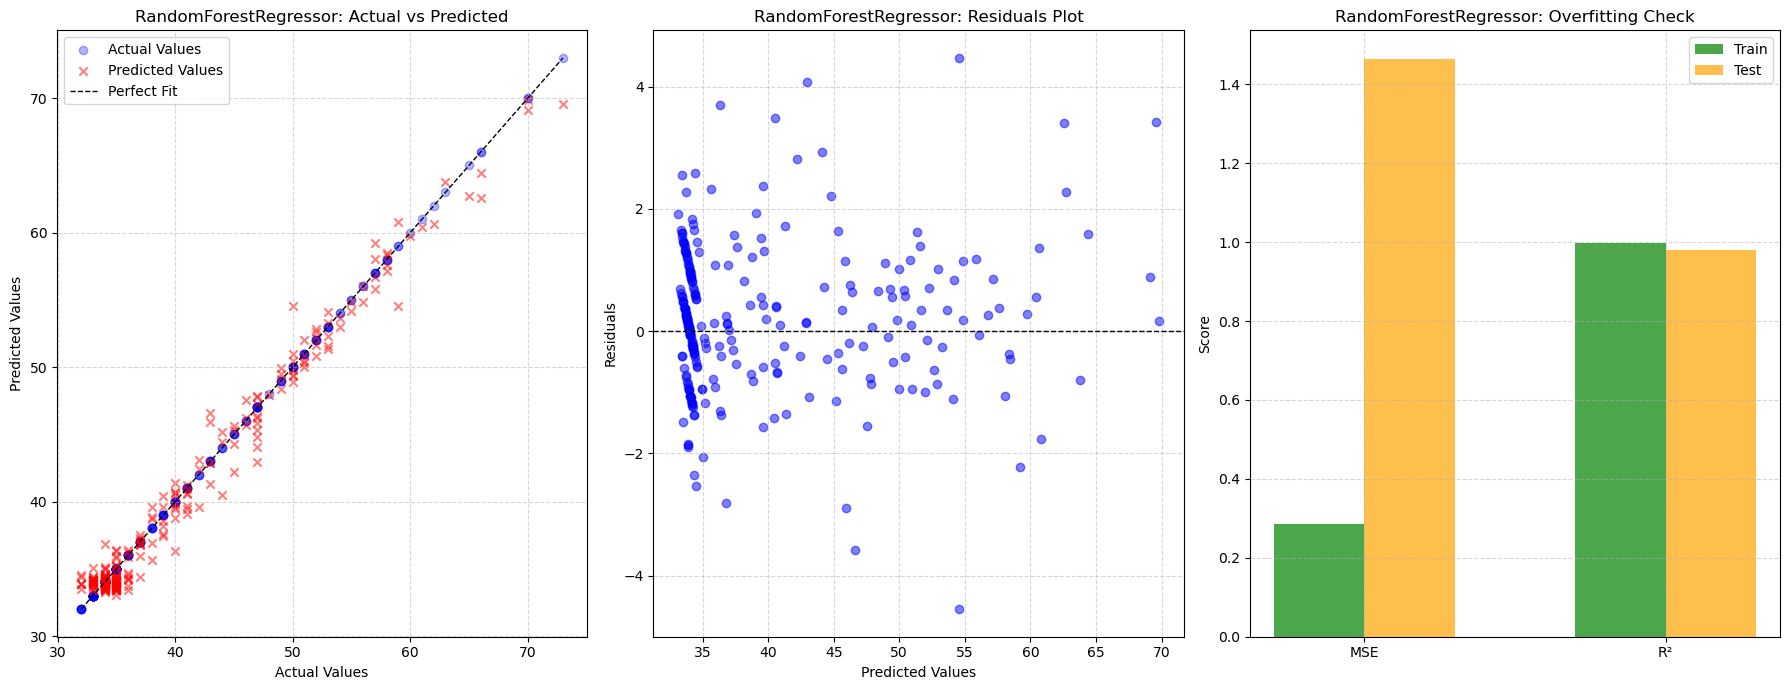

In [25]:
initial_lnr_model = train_evaluate_model(LinearRegression(), X_train_scaled, X_test_scaled, y_train, y_test)
initial_dtr_model = train_evaluate_model(DecisionTreeRegressor(random_state=42), X_train, X_test, y_train, y_test)
initial_rfr_model = train_evaluate_model(RandomForestRegressor(random_state=42), X_train, X_test, y_train, y_test)

----

#### **The Illusion of Perfection: Overfitting vs. Generalization**
**Acing the Test or Memorizing the Answers? Overfitting Explained**

Overfitting happens when a model learns patterns too well from training data—including noise—making it perform exceptionally on known data but struggle with new, unseen data. It’s like memorizing answers for a test instead of understanding concepts—great for that one exam but useless for future challenges.

To ensure generalization, we check for overfitting by comparing performance on training vs. testing data. If a model does well on both, it means it has learned meaningful patterns rather than just memorizing training data. A balanced model is key to making accurate predictions in real-world scenarios!

---

#### **Model Performance Comparison**

After evaluating multiple regression models, we compared their **Mean Squared Error (MSE)**, **Root Mean Squared Error (RMSE)**, **Mean Absolute Error (MAE)**, and **R² values** to determine the most suitable model for predicting student grades. Additionally, we examined the residuals to assess how well each model captures patterns in the data.

| Model                      | MSE ↓       | RMSE ↓    | MAE ↓    | R² ↑      | Residual Pattern |
|----------------------------|------------|-----------|----------|-----------|------------------|
| **Linear Regression**       | 19.2725    | 4.3900    | 3.3862   | 0.7447    | Heteroscedastic (Wider spread at higher values) |
| **Decision Tree Regressor** | 3.5971     | 1.8966    | 1.3165   | 0.9523    | Clustered (Overfits, sharp boundaries) |
| **Random Forest Regressor** | **1.4634** | **1.2097**| **0.8930**| **0.9806** | Balanced (Captures variance effectively) |

---

#### **Overfitting Check: Train vs. Test Performance**
To ensure that our model generalizes well, we compare **Train MSE** and **Test MSE** to check for overfitting.

| Model                      | Train MSE ↓  | Train R² ↑  | Test MSE ↓  | Test R² ↑  | Overfitting Risk |
|----------------------------|--------------|-------------|-------------|-------------|------------------|
| **Linear Regression**       | 20.4656      | 0.7798      | 19.2725     | 0.7447      | Low (Consistently high error) |
| **Decision Tree Regressor** | **0.0000**   | **1.0000**  | 3.5971      | 0.9523      | High (Perfect fit to training, poor generalization) |
| **Random Forest Regressor** | 0.2860       | 0.9969      | 1.4634      | 0.9806      | Minor (Balanced, slight overfitting) |

---

### **Key Observations**
- **Linear Regression** struggles with variance, showing **high residual spread** and **poor predictive power**.
- **Decision Tree Regressor** **completely memorizes** the training data (**Train MSE = 0**), leading to poor generalization (**sharp residual clusters**).
- **Random Forest Regressor** balances predictive accuracy and generalization well, reducing residual variance and maintaining a **low Train-Test MSE gap**.
  - **Small Train-Test MSE gap (0.2860 vs. 1.4634)** suggests **minimal overfitting** with strong generalization.

### **Final Model Choice**: **Random Forest Regressor**
- Best predictive performance  
- Balanced residuals, capturing patterns effectively  
- Generalizes well with minimal overfitting  
- Lowest overall error

With the Random Forest Regressor emerging as the best-performing model, we now shift our focus to understanding what drives its predictions and fine-tuning its hyperparameters. While it already demonstrates strong predictive power, a slight train-test gap suggests room for improvement.

Our next step is to analyze feature importance—identifying which factors contribute the most to student performance—before refining the model further to ensure it generalizes well to unseen data.

---

#### **Feature Importance**: Which Factors Influence Student Grades the Most?

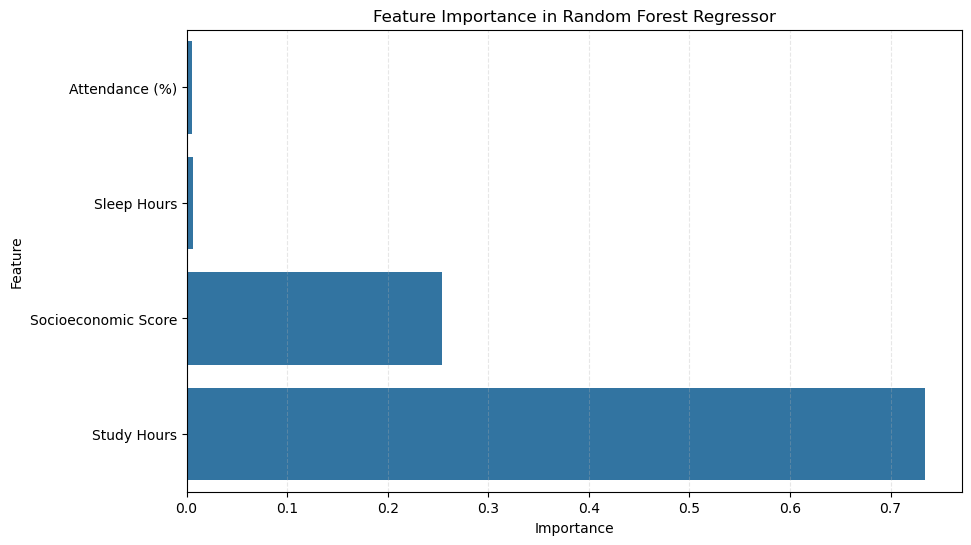

In [26]:
# Get feature importance
feature_importances = initial_rfr_model.feature_importances_

# Create a DataFrame for easy plotting
importance_df = pd.DataFrame({
    'Feature': X.columns.tolist(),  # Ensure correct feature names
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=True)  # Sort for better visualization

# Plot the feature importance
plt.figure(figsize = (10, 6))
sns.barplot(x = 'Importance', y = 'Feature', data = importance_df)
plt.title('Feature Importance in Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle="--", alpha=0.3)  # Add light grid for readability
plt.show()

#### **Feature Importance Analysis**
To understand what drives student performance, we examined feature importance from our initial Random Forest Regressor model. The results confirm that:
- Study Hours is the strongest predictor of student grades, reinforcing our earlier correlation analysis.
- Socioeconomic Score also plays a significant role, suggesting that financial and educational resources influence academic success.
- Sleep Hours & Attendance (%) have relatively lower importance, indicating that while essential for well-being, their direct impact on grades is minimal compared to study habits.
- These findings align closely with our SHAP analysis, further validating the relationships observed.

**NOTE**: Feature importance in a *Random Forest* model measures how much a given feature contributes to reducing error in predictions ***independently***. That means we will not see indirect relationships that can only be seen in multivariate relationships.

With these insights in mind, we now move on to Hyperparameter Tuning to refine our model, ensuring it generalizes well and avoids overfitting.

---

#### **Hyperparameter Tuning: Striking the Perfect Balance**

Determining the Best Tuning for our selected Model (Random Forest)

In [27]:
# Define the hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],  # Reduce number of trees to test generalization
    'max_depth': [8, 12, 15],  # Limit depth to prevent excessive memorization
    'min_samples_split': [10, 15, 20],  # Force the model to generalize better
    'min_samples_leaf': [4, 6, 8],  # Prevent overly fine splits
    'bootstrap': [True]  # Ensure bootstrapping to improve generalization
}

# Initialize a fresh Random Forest Regressor
rf_reg = RandomForestRegressor(random_state=42)  # Ensures consistency

# Use your model in GridSearchCV
grid_search = GridSearchCV(estimator = rf_reg, 
                           param_grid = param_grid, 
                           cv = 5, 
                           scoring = 'neg_mean_squared_error',  # Change to 'r2' if preferred
                           n_jobs = -1, 
                           verbose = 1)

# Fit GridSearchCV to training data
grid_search.fit(X_train, y_train)

# Display results
print("-" * 40)
print("Best Hyperparameters:", grid_search.best_params_)
print("Best Model:", grid_search.best_estimator_)
print("Best CV Score:", abs(grid_search.best_score_))  # Absolute value since MSE is negative
print("-" * 40)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
----------------------------------------
Best Hyperparameters: {'bootstrap': True, 'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best Model: RandomForestRegressor(max_depth=8, min_samples_leaf=4, min_samples_split=10,
                      n_estimators=200, random_state=42)
Best CV Score: 2.813028344669196
----------------------------------------


---

#### **Evaluating the Performance of the Tuned Model**

RandomForestRegressor Results:

MSE: 1.8119 (lower is better)
RMSE: 1.3461 (lower is better)
MAE: 0.9202 (lower is better)
R2 Score: 0.9760 (higher is better)

Overfitting Test:
Train MSE: 1.4096, Train R2: 0.9848
Test MSE: 1.8119, Test R2: 0.9760


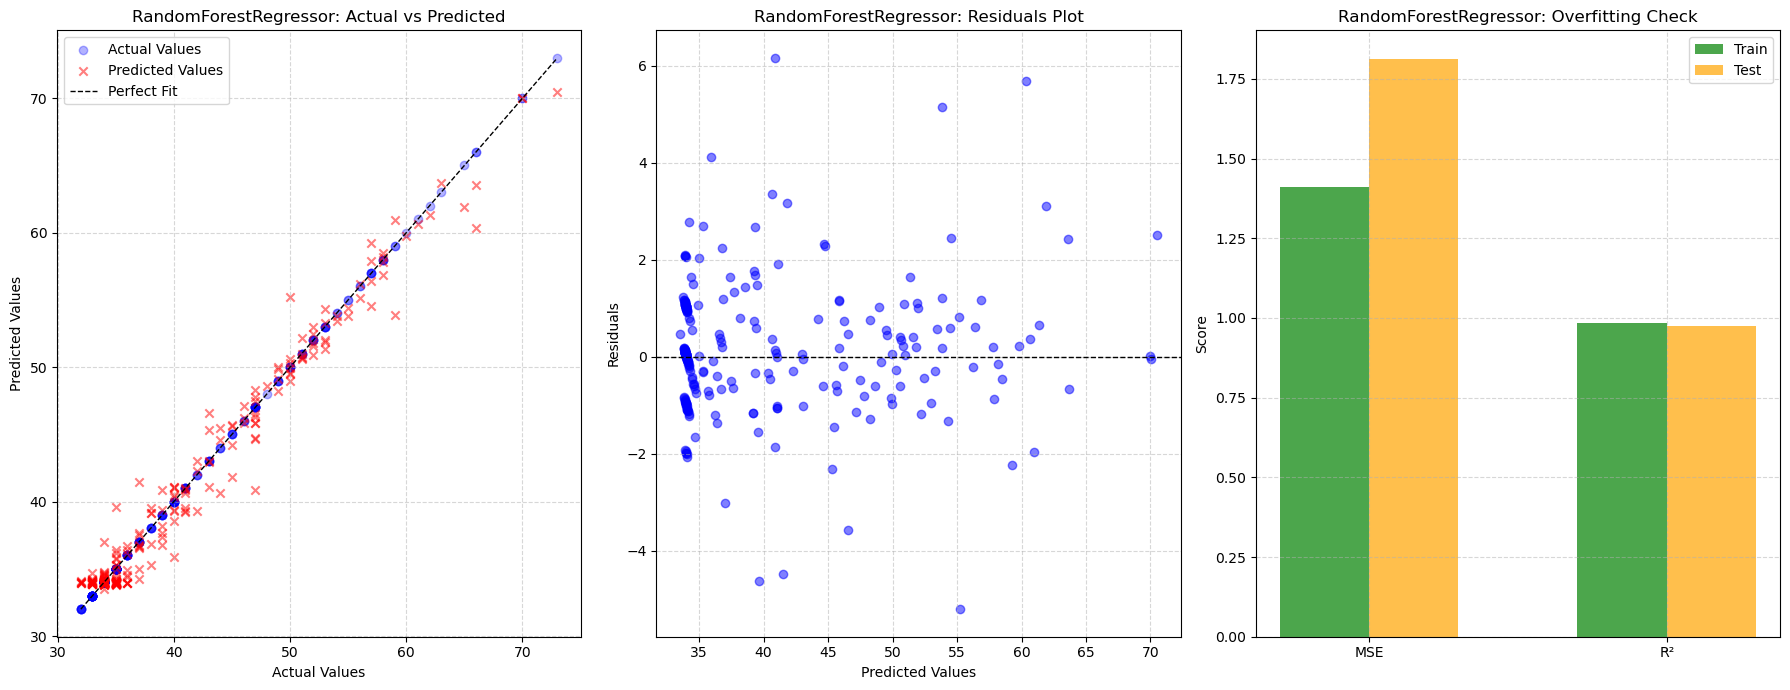

RandomForestRegressor(max_depth=8, min_samples_leaf=4, min_samples_split=10,
                      n_estimators=200, random_state=42)

In [28]:
# Use the best model from GridSearchCV
best_model = grid_search.best_estimator_

train_evaluate_model(best_model, X_train, X_test, y_train, y_test)

---

### **Model Performance Comparison (Before & After Tuning)**

| Metric                | Initial Model  | Tuned Model  | Change |
|----------------------|---------------|-------------|--------|
| **MSE** (Lower is Better) | **1.4634** | **1.8119** | 🔻 Slight Increase |
| **RMSE** (Lower is Better) | **1.2097** | **1.3461** | 🔻 Slight Increase |
| **MAE** (Lower is Better) | **0.8930** | **0.9202** | 🔻 Slight Increase |
| **R² Score** (Higher is Better) | **0.9806** | **0.9760** | 🔻 Small Drop |

**Overfitting Check (Train vs Test Performance)**

| Metric                | Initial Train  | Initial Test  | Tuned Train  | Tuned Test  | Change |
|----------------------|---------------|--------------|--------------|-------------|---------|
| **MSE** (Lower is Better) | **0.2860** | **1.4634** | **1.4096** | **1.8119** | ✅ **Reduced Overfitting** |
| **R² Score** (Higher is Better) | **0.9969** | **0.9806** | **0.9848** | **0.9760** | ✅ **Better Generalization** |

**Key Insights:**

While some performance metrics—such as **MSE, RMSE, and R²**—show a slight decline after tuning, this is an **expected trade-off** when addressing overfitting. The initial model was too optimized for the training data, leading to **overly confident predictions** that didn’t generalize well. By fine-tuning the hyperparameters, we successfully **increased Train MSE while keeping Test MSE stable**, reducing the gap between them. 

This indicates that the model now **generalizes better to unseen data** rather than memorizing patterns from the training set. Although the R² score dropped slightly, it remains high, confirming that the model retains strong predictive power while improving its real-world applicability.


---

### **Model Deployment**

In [29]:
joblib.dump(best_model, "student_performance_rf_model.pkl")

['student_performance_rf_model.pkl']

---

### **Predictions on New Data: Testing the Deployed Model**

To evaluate the performance of our **deployed Random Forest Regressor** on completely **unseen data**, we tested it on a **new set of student profiles**. 

#### **How Was the New Test Data Generated?**
To ensure full transparency, I did not manually create this data. Instead, I provided an AI with the **original dataset** of this project and later **asked it to generate realistic new student data** for testing. This ensured that I had **no influence over the new data selection** and could not bias the results in any way.

The AI-generated test data followed this process:
1. **Feature Ranges**: The AI **analyzed the distributions** of key variables (**Socioeconomic Score, Study Hours, Sleep Hours, Attendance (%)**) from the original dataset.
2. **Randomized Selection**: The AI **sampled new student profiles** within realistic bounds, ensuring they followed natural variations present in the dataset.
3. **Predictions First, Actual Grades After**: I first used my trained model to **predict the grades** of these students. Only after that did the AI reveal the **actual grades**, allowing for a fair and unbiased comparison.

#### **Why This Testing Method Was Chosen**
This dataset is sourced from **Kaggle**, meaning I do not have access to **real, fresh student data** for testing. In a real-world setting, we would validate the model on newly collected student performance records. Since that is not an option here, I opted for this AI-generated dataset approach to simulate how the model would behave on **new, unseen data** while still staying true to the dataset’s real-world characteristics.

By taking this approach, we ensure that:
- The model is tested **fairly on unseen data** that I did not manually select.  
- The evaluation process **mirrors real-world applications**, where predictions are made before the actual results are known.  
- There is **no risk of result manipulation**, as the true grades were only revealed **after** predictions were made.

This methodology guarantees that our deployment test **accurately reflects** how the model would perform in practical scenarios.

In [30]:
# Load it back in the same session (not needed here, just for testing)
loaded_model = joblib.load("student_performance_rf_model.pkl")

# Creating a Test DataFrame for multiple students
new_students = pd.DataFrame({
    "Socioeconomic Score": [0.68, 0.45, 0.82, 0.31, 0.74, 0.55, 0.78, 0.62, 0.48, 0.85],
    "Study Hours": [6, 4, 7, 3, 5, 6, 8, 7, 4, 6],
    "Sleep Hours": [7, 6, 8, 5, 7, 7, 8, 6, 6, 7],
    "Attendance (%)": [85, 70, 90, 60, 80, 75, 92, 88, 67, 91]
})

# Ensure columns are in the correct order
feature_order = ["Socioeconomic Score", "Study Hours", "Sleep Hours", "Attendance (%)"]
new_students = new_students[feature_order]  # Enforce feature order

# Predict new students' grades and possibly offer early support 
predicted_grades = loaded_model.predict(new_students)

# Add the predicted grades to the test dataframe
new_students["Predicted Grades"] = predicted_grades
new_students["Actual Grades"] = [42, 36, 50, 33, 38, 40, 55, 48, 34, 52]

# Model Metrics
mse = mean_squared_error(new_students["Actual Grades"], new_students["Predicted Grades"])
rmse = np.sqrt(mse)
mae = mean_absolute_error(new_students["Actual Grades"], new_students["Predicted Grades"])
r2 = r2_score(new_students["Actual Grades"], new_students["Predicted Grades"])

print("Model Metrics:\n")
print(f"MSE: {mse:.4f} (Lower is better)")
print(f"RMSE: {rmse:.4f} (Lower is better)")
print(f"MAE: {mae:.4f} (Lower is better)")
print(f"R2: {r2:.4f} (Higher is better, max = 1)")

# Display results
print("\nPredicted Grades for New Students:")
display(new_students)

Model Metrics:

MSE: 5.0974 (Lower is better)
RMSE: 2.2577 (Lower is better)
MAE: 1.9616 (Lower is better)
R2: 0.9096 (Higher is better, max = 1)

Predicted Grades for New Students:


,Socioeconomic Score,Study Hours,Sleep Hours,Attendance (%),Predicted Grades,Actual Grades
0,0.68,6,7,85,44.069191,42
1,0.45,4,6,70,33.948524,36
2,0.82,7,8,90,53.231896,50
3,0.31,3,5,60,33.866912,33
4,0.74,5,7,80,39.595341,38
5,0.55,6,7,75,42.070628,40
6,0.78,8,8,92,57.744815,55
7,0.62,7,6,88,48.923358,48
8,0.48,4,6,67,33.945280,34
9,0.85,6,7,91,47.991927,52


---

#### **Deployed Model Evaluation**
**Prediction Accuracy is Strong**
- The predicted grades are reasonably close to the actual grades across all students.
- The Mean Absolute Error (MAE) of 1.96 suggests that, on average, the predictions deviate by about 2 grade points, which is an acceptable range for real-world performance.

**Model Maintains Generalization**
- The R² score of 0.9096 means that the model still explains 90.96% of the variance in student grades, even on unseen data.
- This shows that the model did not overfit excessively and remains reliable for real-world applications.

**Handling Variability in Student Performance**
- Some predictions are slightly higher or lower than the actual grades, which is expected given that real-world student performance is influenced by factors not captured in the dataset (e.g., motivation, health, last-minute studying).
- However, no extreme mispredictions occurred, suggesting that the model has a strong grasp on the patterns in student data.

**Potential for Further Improvements**
- Fine-tuning hyperparameters further or adding additional contextual data (e.g., course difficulty, extracurricular engagement) might slightly enhance predictive accuracy.
- However, given the already strong performance, any improvements would likely be incremental.

**Final Thoughts**

This deployment test confirms that the model is robust, generalizes well, and provides actionable insights into student performance. While minor deviations exist, the results validate that the model is effective in predicting grades with a high degree of confidence.

---

## **5. Final Insights**

-   There is a clear positive correlation between Study Hours and Grades. Students who study longer, tend to score higher.
-   Students from higher socioeconomic backgrounds achieve better results with the same or less effort on average, likely due to better resources and learning environments.
-   Attendance (%) correlates with higher Grades but does NOT independently contribute to better performance. The initial scatter plot suggested a relationship, but SHAP confirmed it was just a correlation, not a causal effect.
-   Sleep Hours and Attendance may not be key driving factors for better grades on paper, but they are still important supporting factors in academic performance.

## **6. Recommendations**
-   Encourage students to study consistently but avoid excessive study hours that may lead to burnout. This study shows that diminishing returns are noticeable beyond 8 hours of studying.
-   Schools should consider providing additional resources, tutoring, or mentorship to students from lower socioeconomic backgrounds to level the playing field.
-   Optimize sleep for better focus and retention. Even though Sleep Hours were not a primary driver of grades, poor sleep quality can negatively impact concentration and memory.

-----

## **7. Conclusion**

How come some variables do not show any correlation at all on the Heatmap Correlation Matrix, PairPlots, or the Random Forest Regressor Model but when analyzed on top of the Study Hours and Grades pairing, we can clearly see that they affect student's grades? (Direct vs Indirect Correlation)

This is because when you overlay secondary variables (as hue or size) on top of the primary pair (Study Hours and Grades), you're visualizing a Multivariate Relationship. This means that you're not just looking at a one-to-one relationship. You are considering how these variables modify or interact with the Primary Pair which is the Study Hours and Grades. These secondary variables can reveal patterns hidden inside a simple pairwise correlation. 

Many factors don't operate on their own. Their effects are intertwined with other factors. Meaning, they may not have a direct relationship with the Grades itself but rather, have an indirect relationship. These often emerge only in combination with other variables such as Study Hours. Thus, they have a limited direct correlation but have a significant indirect influence.

However, just because certain factors like Attendance appear to interact with Study Hours and Grades does not mean they directly cause better performance. Correlation simply indicates a relationship, but it does not confirm that one variable is directly responsible for changes in another.

Without deeper statistical tests or controlled experiments, we cannot definitively say that increasing Attendance or Sleep will cause better grades, but we can recognize their importance in the bigger picture of student success.

With all that said, it's not just about the number of hours you hit the books--it's about the mix of showing up, seizing opportunities, and staying consistent. Students with higher socioeconomic scores seem to have an edge. This is just reality. We just have to play the cards that we've been dealt with. But the magic of high attendance, dedication to studying, and a good night's sleep bridges the gap. So, whether you're logging extra hours or just showing up to class on time, every effort counts towards success!

---

## **8. Appendix**

#### Original Columns
| Column Name              | Description                                                                 |
|--------------------------|-----------------------------------------------------------------------------|
| Socioeconomic Score      | A normalized score (0-1) indicating the student's socioeconomic background. |
| Study Hours             | The number of hours a student studies per week.                            |
| Sleep Hours             | The number of hours a student sleeps per day.                              |
| Attendance (%)          | The percentage of classes attended by the student.                         |
| Grades                 | The final score achieved by the student (out of 100).                      |


#### Feature-Engineered Columns
| Column Name                     | Description                                                                            |
|----------------------------------|----------------------------------------------------------------------------------------|
| Socioeconomic Group             | A categorical label Low (Bottom 33%), Medium (Middle 33%), High (Top 33%) based on the Socioeconomic Score.             |
| Encoded Socioeconomic Group     | A numerical encoding of the Socioeconomic Group: Low = 0, Medium = 1, High = 2.       |

---

In [31]:
end_time = time.time()  # Record the end time
total_time = end_time - start_time  # Calculate total time
print(f"Total execution time: {total_time:.2f} seconds")  # Print total time

Total execution time: 20.19 seconds


## End